<a href="https://colab.research.google.com/github/Isabella-Costa/Imputacao_Dados_Faltantes/blob/main/Ana%CC%81lise_de_Se%CC%81ries_Temporais_com_FFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução a FFT

A transformada Rápida de fourier é uma técnica matemática para decompor um sinal no tempo (como som, uma série temporal ou uma imagem) em suas frequências constituintes.


Imagine que você está ouvindo uma música: ela é composta por diversas notas(freq) tocadas ao mesmo tempo. A - FFT é como um "detector de notas", que separa cada freq presente na música.


# Como Funciona


1.   **Sinal no tempo** -> Um sinal é representado como uma função de tempo, por exemplo, a variação de preço de um ativo ao longo dos dias.
2.   **Sinal no domínio da frequência** -> A FFT transforma o sinal do tempo em um gráfico que mostra:

*   As frequências presentes no sinal
*   A amplitude de cada frequeência
3. **Velocidade** -> A FFT é uma versão otimizada da Transformada de Fourier, que calcula essa transformação muito mais rápido.



# Casos de uso
Análise de séries temporais:
- Identificar padrôes sazonais
- Detectar tendências ou ciclos em séries temporais




Sinal 1
Sinal 2
Sinal 3


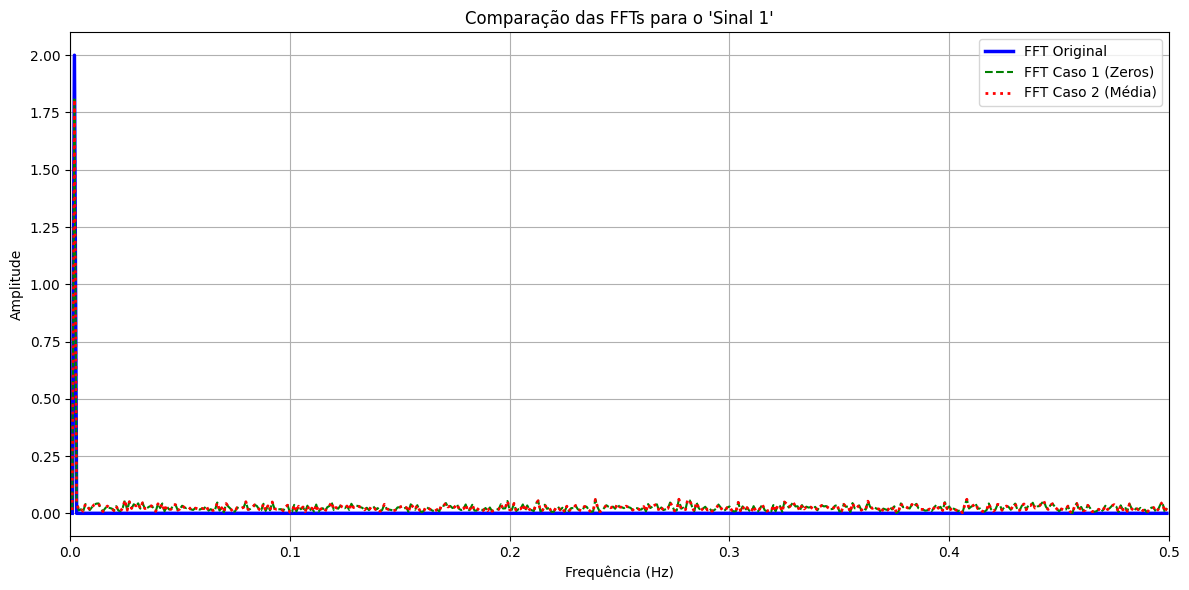

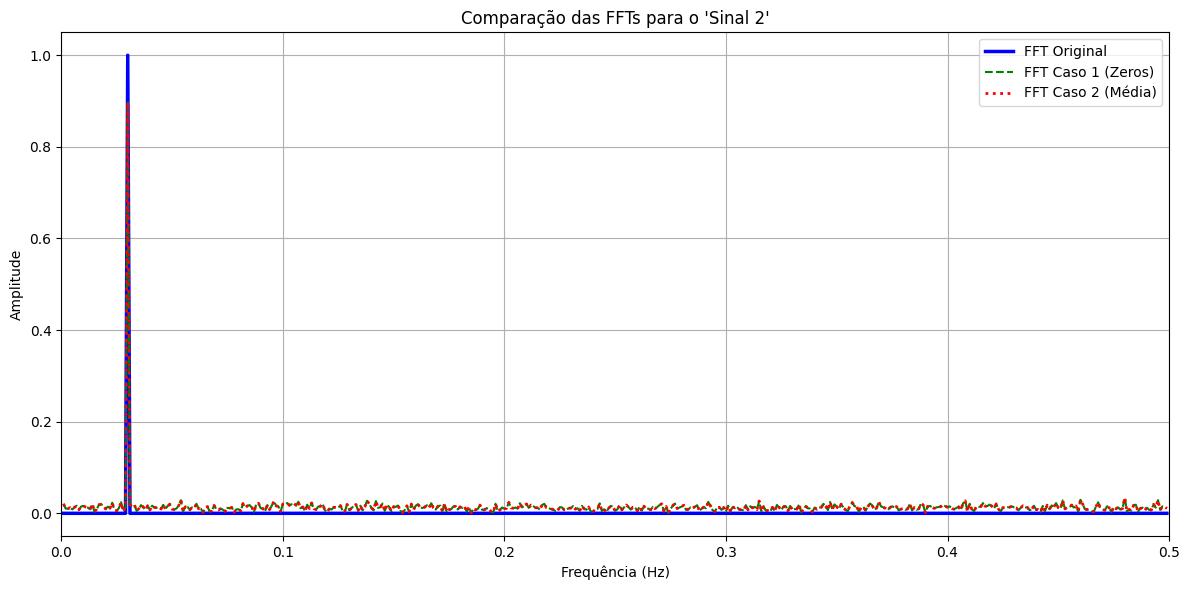

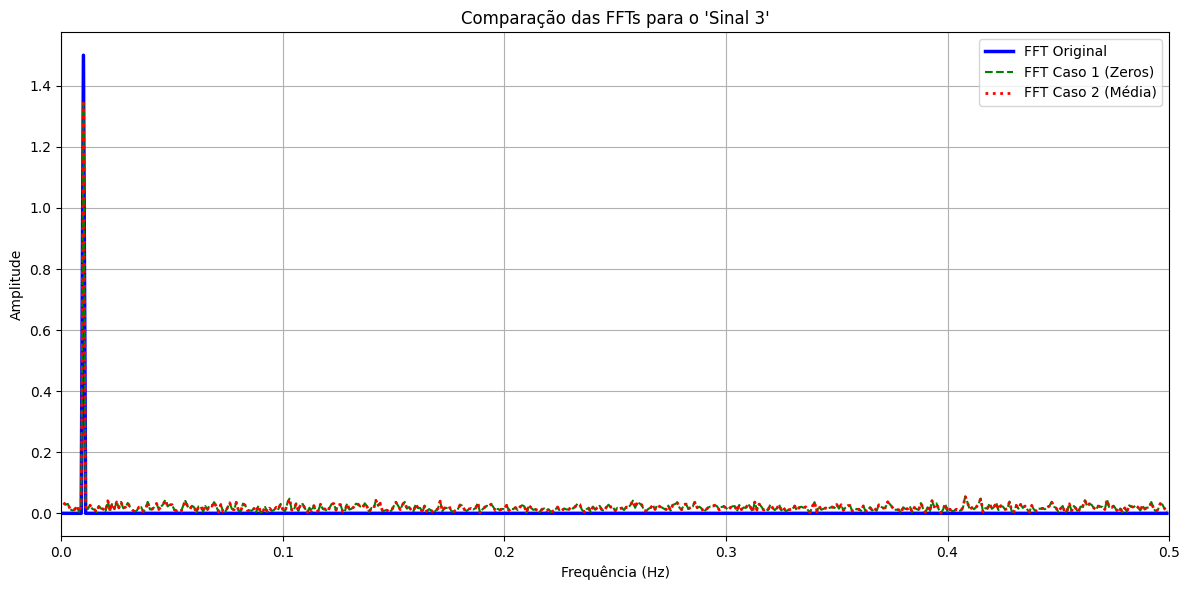

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


n= 1000 # número de pontos
tx = 200 # tamanho do eixo X
taxa_amostragem = n/tx

# freq angular
w= 2.0 * np.pi / tx
# eixo do tempo
t = np.linspace(0.0, tx, n, endpoint=False)
freq = np.fft.fftfreq(n)
mask = np.where(freq > 0)
# SINAIS
signal_1 = 2.0 * np.cos(2 * w * t)
signal_2 = 1.0 * np.cos(30.0 * w * t)
signal_3 = 1.5 * np.sin(10 * w * t)
#signal = signal_1 + signal_2 + signal_3


def toAnalyzeSignal(signal, titleSignal):

    print(titleSignal)

    fourier = np.fft.fft(signal)
    fft_absolute = 2.0* np.abs(fourier/n)

    # Sinal com falhas
    signal_with_nan = signal.copy()
    number_remove = int(0.1*n)
    index_remove = np.random.choice(n, number_remove, replace=False)
    signal_with_nan[index_remove] = np.nan

    # Imputação por ZEROS
    imputed_zeros_signal = signal_with_nan.copy()
    imputed_zeros_signal[np.isnan(imputed_zeros_signal)] = 0
    imputed_zeros_fourier = np.fft.fft(imputed_zeros_signal)
    imputed_zeros_fft_absolute = 2.0* np.abs(imputed_zeros_fourier/n)

    # Imputação por média
    mean_value = np.nanmean(signal_with_nan)
    imputed_mean_signal = signal_with_nan.copy()
    imputed_mean_signal[np.isnan(imputed_mean_signal)] = mean_value
    imputed_mean_fourier = np.fft.fft(imputed_mean_signal)
    imputed_mean_fft_absolute = 2.0* np.abs(imputed_mean_fourier/n)

    #Plotagem
    plt.figure(figsize=(12, 6))
    plt.title(f"Comparação das FFTs para o '{titleSignal}'")
    plt.plot(freq[mask], fft_absolute[mask], 'b-', label='FFT Original', linewidth=2.5)
    plt.plot(freq[mask], imputed_zeros_fft_absolute[mask], 'g--', label='FFT Caso 1 (Zeros)')
    plt.plot(freq[mask], imputed_mean_fft_absolute[mask], 'r:', label='FFT Caso 2 (Média)', linewidth=2)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, max(np.max(freq), 0.5))
    plt.tight_layout()



toAnalyzeSignal(signal_1, 'Sinal 1')
toAnalyzeSignal(signal_2, 'Sinal 2')
toAnalyzeSignal(signal_3, 'Sinal 3')
plt.show()

Sinal 1
Sinal 2
Sinal 3


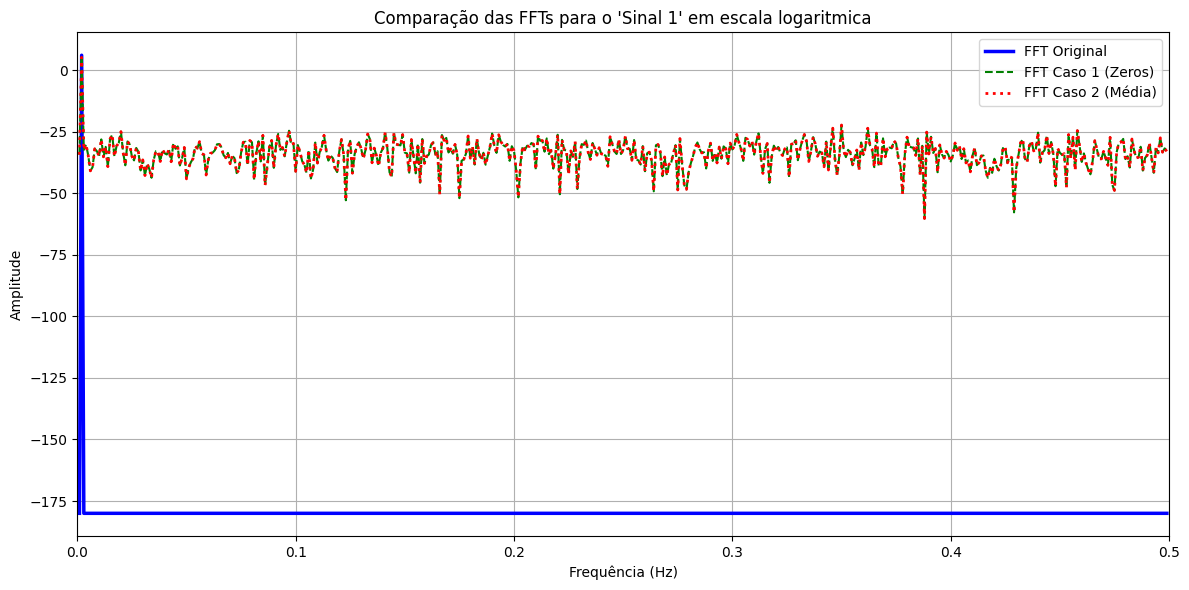

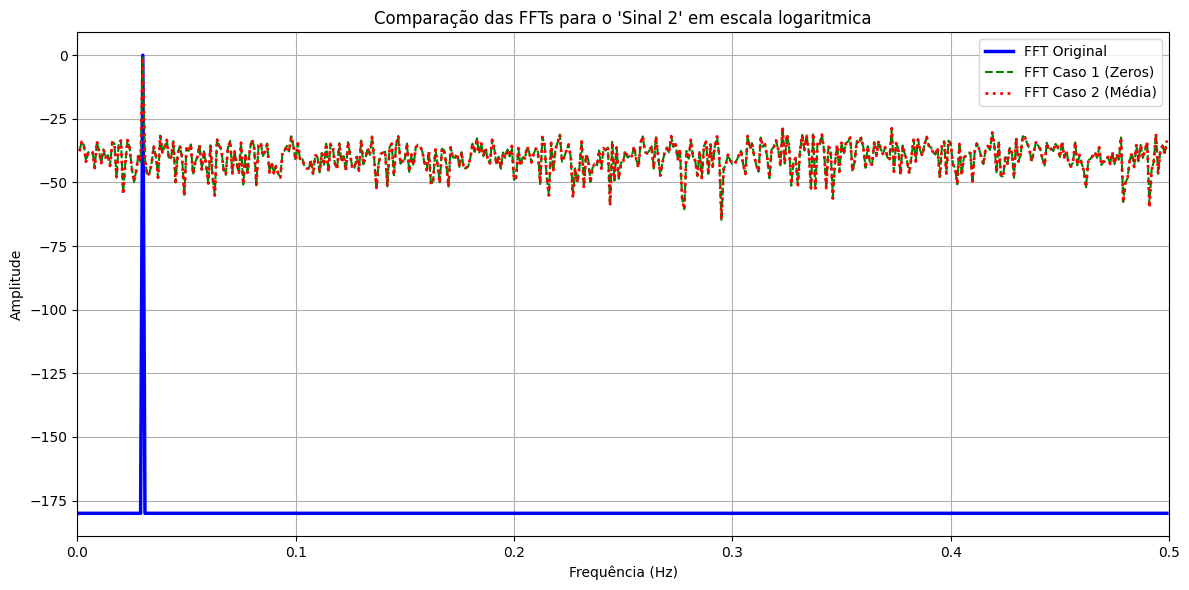

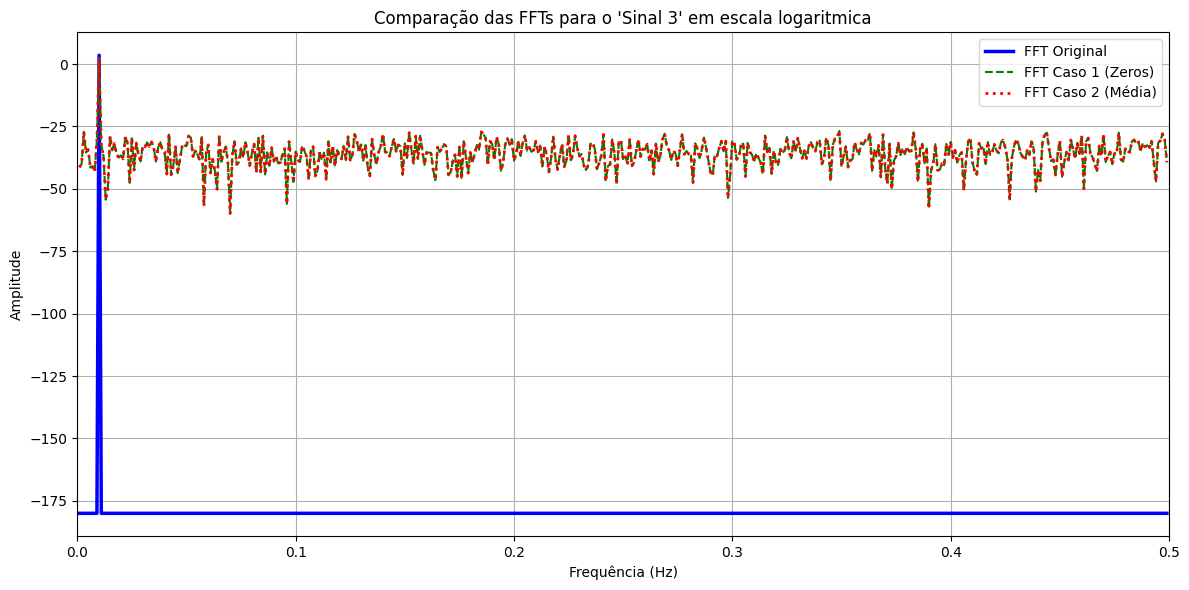

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


n= 1000 # número de pontos
tx = 200 # tamanho do eixo X
taxa_amostragem = n/tx

# freq angular
w= 2.0 * np.pi / tx
# eixo do tempo
t = np.linspace(0.0, tx, n, endpoint=False)
freq = np.fft.fftfreq(n)
mask = np.where(freq > 0)
# SINAIS
signal_1 = 2.0 * np.cos(2 * w * t)
signal_2 = 1.0 * np.cos(30.0 * w * t)
signal_3 = 1.5 * np.sin(10 * w * t)
#signal = signal_1 + signal_2 + signal_3


def toAnalyzeSignal(signal, titleSignal):

    print(titleSignal)

    fourier = np.fft.fft(signal)
    fft_absolute = 2.0* np.abs(fourier/n)

    # Sinal com falhas
    signal_with_nan = signal.copy()
    number_remove = int(0.1*n)
    index_remove = np.random.choice(n, number_remove, replace=False)
    signal_with_nan[index_remove] = np.nan

    # Imputação por ZEROS
    imputed_zeros_signal = signal_with_nan.copy()
    imputed_zeros_signal[np.isnan(imputed_zeros_signal)] = 0
    imputed_zeros_fourier = np.fft.fft(imputed_zeros_signal)
    imputed_zeros_fft_absolute = 2.0* np.abs(imputed_zeros_fourier/n)

    # Imputação por média
    imputed_mean_signal = signal_with_nan.copy()
    mean_value = np.nanmean(signal_with_nan)
    imputed_mean_signal[np.isnan(imputed_mean_signal)] = mean_value
    imputed_mean_fourier = np.fft.fft(imputed_mean_signal)
    imputed_mean_fft_absolute = 2.0* np.abs(imputed_mean_fourier/n)


    # Converte para escala logarítmica
    fft_absolute = 20 * np.log10(fft_absolute + 1e-9)
    imputed_zeros_fft_absolute = 20 * np.log10(imputed_zeros_fft_absolute + 1e-9)
    imputed_mean_fft_absolute = 20 *np.log10(imputed_mean_fft_absolute + 1e-9)

    #Plotagem
    plt.figure(figsize=(12, 6))
    plt.title(f"Comparação das FFTs para o '{titleSignal}' em escala logaritmica")
    plt.plot(freq[mask], fft_absolute[mask], 'b-', label='FFT Original', linewidth=2.5)
    plt.plot(freq[mask], imputed_zeros_fft_absolute[mask], 'g--', label='FFT Caso 1 (Zeros)')
    plt.plot(freq[mask], imputed_mean_fft_absolute[mask], 'r:', label='FFT Caso 2 (Média)', linewidth=2)
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, max(np.max(freq), 0.5))
    plt.tight_layout()



toAnalyzeSignal(signal_1, 'Sinal 1')
toAnalyzeSignal(signal_2, 'Sinal 2')
toAnalyzeSignal(signal_3, 'Sinal 3')
plt.show()

A Definição Original do Decibel (Baseada em Potência):
O Decibel (dB) foi originalmente criado para medir uma razão entre duas potências (P1 e P2)

dB = 10 * log10 (P1/P2)

**A potência de um sinal ou onda é diretamente proporcional ao quadrado da sua amplitude.**

dB = 10 * log10 ((A1/A2)^2)

dB = 10 * 2 * log10 (A1/A2)

    fft_absolute = 20 * np.log10(fft_absolute)
